# 🏠 Individual Household Electric Power Consumption
### UCI ML Repository — Dataset #235

**Goal:** Predict `Global_active_power` (household electricity consumption in kilowatts)  
**Strategy:** Rich feature engineering from timestamps + physics-based features → ensemble models → high R² score

| Step | Description |
|------|-------------|
| 1 | Load & inspect raw data |
| 2 | Clean missing values & fix dtypes |
| 3 | Feature engineering (temporal, lag, rolling, physics) |
| 4 | Model training (Linear, RF, XGBoost, LightGBM) |
| 5 | Evaluation & comparison |

---
## 1. Setup & Data Loading

In [ ]:
# ── Install dependencies if needed ────────────────────────────────────────────
import subprocess, sys

pkgs = [
    "ucimlrepo",
    "xgboost",
    "lightgbm",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
]
subprocess.run(
    [sys.executable, "-m", "pip", "install", *pkgs, "-q", "--break-system-packages"],
    capture_output=True,
)

In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

# Plotting style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42
np.random.seed(SEED)
print("✅  Libraries loaded")

✅  Libraries loaded


In [ ]:
# ── Load dataset from UCI ──────────────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=235)
raw_df = dataset.data.features.copy()  # type: ignore

print(f"Dataset : {dataset.metadata['name']}")
print(f"Shape   : {raw_df.shape}")
print(f"Columns : {raw_df.columns.tolist()}")
raw_df.head()

In [2]:
BASE_PATH = Path(".")
DATA_PATH = BASE_PATH.resolve() / "data"
path = next(DATA_PATH.glob("*"))

raw_df = pd.read_csv(path, delimiter=";")
raw_df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
# ── Basic info & missing values ────────────────────────────────────────────────
print("--- dtypes ---")
print(raw_df.dtypes)
print("\n--- Missing / '?' values ---")
missing = (raw_df == "?").sum() + raw_df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing: {missing.sum():,}  ({missing.sum()/len(raw_df)*100:.2f}%)")

--- dtypes ---
Date                         str
Time                         str
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

--- Missing / '?' values ---


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Total missing: 181,853  (8.76%)


---
## 2. Data Cleaning & Type Conversion

In [4]:
df = raw_df.copy()

# ── Replace '?' with NaN then cast numeric columns ────────────────────────────
num_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c].replace("?", np.nan), errors="coerce")

# ── Build datetime index ───────────────────────────────────────────────────────
df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce",
)
df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()
df = df.drop(columns=["Date", "Time"])

# ── Drop rows missing the target ───────────────────────────────────────────────
before = len(df)
df = df.dropna(subset=["Global_active_power"])
print(f"Rows dropped (target NaN) : {before - len(df):,}")

# ── Fill remaining NaNs with forward-fill then median ─────────────────────────
df[num_cols] = df[num_cols].ffill().fillna(df[num_cols].median())

# ── Resample to 30-minute intervals ───────────────────────────────────────────
df = df.resample("30min").mean()
df[num_cols] = df[num_cols].ffill().fillna(df[num_cols].median())
print("✅  Resampled to 30-minute intervals")

print(f"\nClean shape : {df.shape}")
print(f"Date range  : {df.index.min()} → {df.index.max()}")
df.head()

Rows dropped (target NaN) : 25,979
✅  Resampled to 30-minute intervals

Clean shape : (69177, 7)
Date range  : 2006-12-16 17:00:00 → 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.587333,0.484000,234.366667,19.700000,0.0,1.333333,16.833333
2006-12-16 17:30:00,4.150000,0.178000,234.699333,17.780000,0.0,0.366667,16.866667
2006-12-16 18:00:00,3.944800,0.084867,235.184667,16.966667,0.0,11.400000,16.966667
2006-12-16 18:30:00,3.319600,0.075200,233.975667,14.233333,0.0,2.033333,16.766667
2006-12-16 19:00:00,3.464400,0.049800,233.754000,14.746667,0.0,1.833333,16.766667


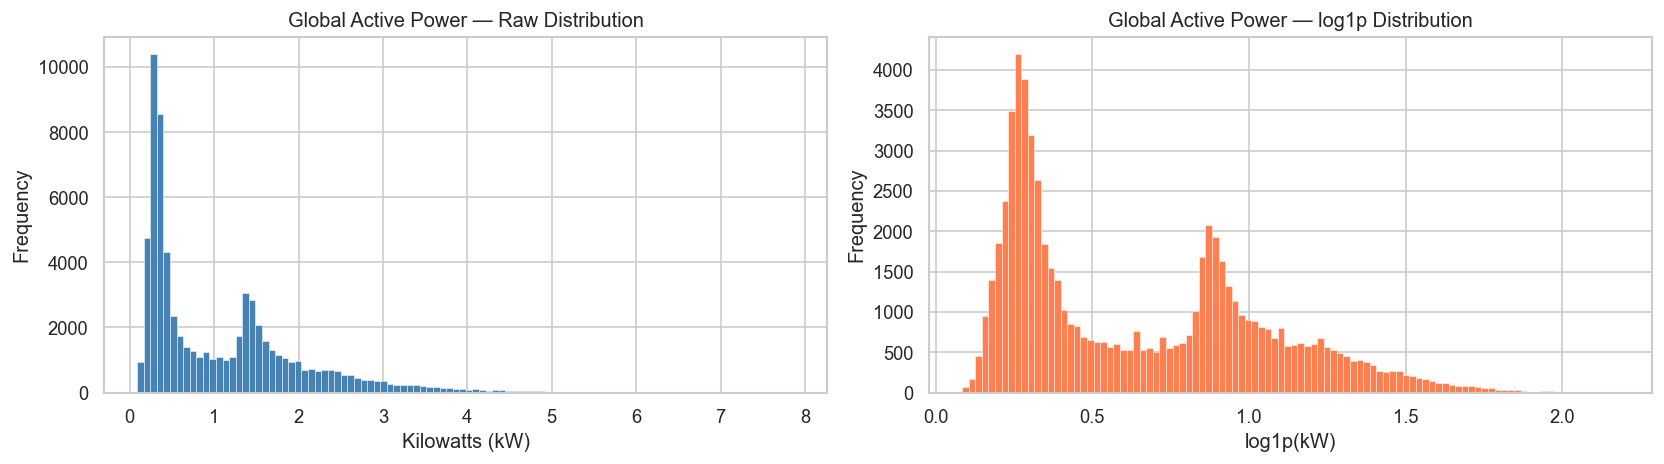

In [5]:
# ── Distribution of target variable ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    df["Global_active_power"],
    bins=100,
    color="steelblue",
    edgecolor="white",
    linewidth=0.3,
)
axes[0].set_title("Global Active Power — Raw Distribution")
axes[0].set_xlabel("Kilowatts (kW)")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    np.log1p(df["Global_active_power"]),
    bins=100,
    color="coral",
    edgecolor="white",
    linewidth=0.3,
)
axes[1].set_title("Global Active Power — log1p Distribution")
axes[1].set_xlabel("log1p(kW)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

We extract four groups of features to give the models rich predictive signal:

| Group | Examples |
|-------|----------|
| **Temporal** | hour, day-of-week, month, is_weekend, season, time-of-day cyclical encoding |
| **Lag features** | target at 1–10, 20 periods back (30 min–10 hr), t-1 day, t-1 week (48/336 periods) |
| **Rolling statistics** | rolling mean/std/min/max over 4, 12, 48 period windows (2 hr / 6 hr / 1 day) — window=1 excluded (equals current value) |
| **Physics-derived** | sub_metering_total only — leaky sensor cols (Voltage, Global_intensity) excluded |

In [ ]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    gap = d["Global_active_power"]  # shorthand

    # ── Temporal features ─────────────────────────────────────────────────────
    d["hour"] = d.index.hour  # type: ignore
    d["minute"] = d.index.minute  # type: ignore
    d["dayofweek"] = d.index.dayofweek  # type: ignore
    d["dayofyear"] = d.index.dayofyear  # type: ignore
    d["month"] = d.index.month  # type: ignore
    d["year"] = d.index.year  # type: ignore
    d["is_weekend"] = (d.index.dayofweek >= 5).astype(int)  # type: ignore
    d["quarter"] = d.index.quarter  # type: ignore

    # Season
    d["season"] = d["month"].map(
        {
            12: 0,
            1: 0,
            2: 0,  # Winter
            3: 1,
            4: 1,
            5: 1,  # Spring
            6: 2,
            7: 2,
            8: 2,  # Summer
            9: 3,
            10: 3,
            11: 3,  # Autumn
        }
    )

    # Time-of-day bins: night/morning/afternoon/evening
    d["time_of_day"] = pd.cut(
        d["hour"], bins=[-1, 5, 11, 17, 23], labels=[0, 1, 2, 3]
    ).astype(int)

    # Cyclical encoding (avoids discontinuity at 23→0, Dec→Jan, etc.)
    d["hour_sin"] = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"] = np.cos(2 * np.pi * d["hour"] / 24)
    d["dow_sin"] = np.sin(2 * np.pi * d["dayofweek"] / 7)
    d["dow_cos"] = np.cos(2 * np.pi * d["dayofweek"] / 7)
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)
    d["doy_sin"] = np.sin(2 * np.pi * d["dayofyear"] / 365)
    d["doy_cos"] = np.cos(2 * np.pi * d["dayofyear"] / 365)

    # ── Physics-derived features ──────────────────────────────────────────────
    # NOTE: Voltage and Global_intensity are intentionally excluded as features.
    # By Ohm's law, P ≈ V × I / 1000, so they nearly reconstruct the target
    # algebraically and cause artificially inflated R² scores.
    # apparent_power, power_factor, unmeasured, and reactive_ratio are also
    # excluded for the same reason — they are all derived from those leaky columns.
    #
    # Sub-metering totals are kept: they measure specific appliance loads and do
    # not directly reconstruct Global_active_power.
    d["sub_total"] = d["Sub_metering_1"] + d["Sub_metering_2"] + d["Sub_metering_3"]

    # ── Lag features ─────────────────────────────────────────────────────────
    # Lags in 30-min periods: 1=30m, 2=1h, 3=1.5h, 5=2.5h, 10=5h, 20=10h, 48=1day, 336=1week
    for lag in [1, 2, 3, 5, 10, 20, 48, 336]:  # 30-min periods
        d[f"lag_{lag}"] = gap.shift(lag)

    # ── Rolling statistics ────────────────────────────────────────────────────
    # Rolling windows in 30-min periods: 4=2h, 12=6h, 48=1day
    # IMPORTANT: shift(1) before rolling so the window is [t-w … t-1].
    # Without shift, rolling(w) at time t includes the current target value,
    # which is pure leakage for a prediction task.
    gap_lagged = gap.shift(1)
    for w in [4, 12, 48]:  # 30-min periods
        rolled = gap_lagged.rolling(window=w, min_periods=1)
        d[f"roll_mean_{w}"] = rolled.mean()
        d[f"roll_std_{w}"] = rolled.std().fillna(0)
        d[f"roll_min_{w}"] = rolled.min()
        d[f"roll_max_{w}"] = rolled.max()

    # ── Interaction features ──────────────────────────────────────────────────
    d["hour_x_weekend"] = d["hour"] * d["is_weekend"]
    d["hour_x_season"] = d["hour"] * d["season"]

    return d


# engineer_features is called separately on train and test after the split.
# This prevents rolling statistics computed on the full dataset from leaking
# future (test-set) values into training-time features.
# The actual calls are in the "Train / Test Split" cell below.
print("✅  engineer_features() defined — will be called after split")

✅  engineer_features() defined — will be called after split


In [ ]:
TARGET = "Global_active_power"
# Exclude target and raw sensor columns that near-perfectly reconstruct it
# Leaky sensor cols already removed from df_clean above; only drop the target here
DROP = [TARGET]

# Drop leaky raw sensor columns before any feature engineering
# (they are excluded from FEATURES via DROP but cleaner to remove upfront)
RAW_LEAKY = ["Voltage", "Global_intensity", "Global_reactive_power"]
df_clean = df.drop(columns=[c for c in RAW_LEAKY if c in df.columns])

# Chronological 80/20 split on the raw cleaned data BEFORE feature engineering
split_ts = df_clean.index[int(len(df_clean) * 0.80)]
df_raw_train = df_clean[df_clean.index < split_ts]
df_raw_test = df_clean[df_clean.index >= split_ts]
print(
    f"Raw train : {df_raw_train.shape}  ({df_raw_train.index.min()} → {df_raw_train.index.max()})"
)
print(
    f"Raw test  : {df_raw_test.shape}  ({df_raw_test.index.min()} → {df_raw_test.index.max()})"
)
print(f"Leaky cols removed: {RAW_LEAKY}")

# Engineer features on train only, then on the concatenated series so that
# test lags/rolling windows look back into the training tail (as they would
# in production) but the rolling stats are never computed using test targets.
print("⚙️  Engineering features (train) …")
df_feat_train = engineer_features(df_raw_train).dropna()

# For the test set: concatenate the last max_lag rows of train as context,
# engineer features, then slice back to only the test rows.
MAX_LAG = 336  # 1 week — the longest lag used
context = df_raw_train.iloc[-MAX_LAG:]
df_feat_test_full = engineer_features(pd.concat([context, df_raw_test]))
df_feat_test = df_feat_test_full.loc[df_raw_test.index].dropna()
print(
    f"✅  Train features: {df_feat_train.shape}   Test features: {df_feat_test.shape}"
)

FEATURES = [c for c in df_feat_train.columns if c not in DROP]

X_train = df_feat_train[FEATURES].astype(np.float32)
y_train = df_feat_train[TARGET].astype(np.float32)
X_test = df_feat_test[FEATURES].astype(np.float32)
y_test = df_feat_test[TARGET].astype(np.float32)

# Keep split_idx for downstream cells that reference df_feat
df_feat = pd.concat([df_feat_train, df_feat_test])
split_idx = len(df_feat_train)

print(f"\nFeatures : {len(FEATURES)}")
print(f"Train    : {X_train.shape}")
print(f"Test     : {X_test.shape}")

Raw train : (55341, 4)  (2006-12-16 17:00:00 → 2010-02-11 15:00:00)
Raw test  : (13836, 4)  (2010-02-11 15:30:00 → 2010-11-26 21:00:00)
Leaky cols removed: ['Voltage', 'Global_intensity', 'Global_reactive_power']
⚙️  Engineering features (train) …
✅  Train features: (55005, 45)   Test features: (13836, 45)

Features : 44
Train    : (55005, 44)
Test     : (13836, 44)


---
## 4. Train / Test Split

We use a **chronological split** (no shuffling) — the last 20 % of time is held out as the test set to simulate real-world forecasting.

In [8]:
# Train/test split was performed in the feature-engineering cell above.
# Here we just fit the scaler on training data only (for Ridge).
print(f"Train : {X_train.shape}  ({X_train.index.min()} → {X_train.index.max()})")
print(f"Test  : {X_test.shape}  ({X_test.index.min()} → {X_test.index.max()})")

# Scaler (only needed for Ridge) — fit on train, apply to test
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

Train : (55005, 44)  (2006-12-23 17:00:00 → 2010-02-11 15:00:00)
Test  : (13836, 44)  (2010-02-11 15:30:00 → 2010-11-26 21:00:00)


---
## 5. Model Training

In [9]:
results = {}


def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    results[name] = {"R²": r2, "MAE": mae, "RMSE": rmse}
    print(f"  R²={r2:.6f}   MAE={mae:.5f}   RMSE={rmse:.5f}")
    return y_pred

In [10]:
# ── 5.1  Ridge Regression (baseline) ──────────────────────────────────────────
print("🔷  Ridge Regression …")
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_sc, y_train)
y_pred_ridge = evaluate("Ridge", y_test, ridge.predict(X_te_sc))

🔷  Ridge Regression …
  R²=0.870628   MAE=0.20141   RMSE=0.28071


In [11]:
# ── 5.2  Random Forest ────────────────────────────────────────────────────────
print("🌲  Random Forest …")
rf = RandomForestRegressor(
    n_estimators=50, max_depth=4, min_samples_leaf=4, n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)
y_pred_rf = evaluate("RandomForest", y_test, rf.predict(X_test))

🌲  Random Forest …
  R²=0.842870   MAE=0.21088   RMSE=0.30937


In [12]:
# ── 5.3  XGBoost ──────────────────────────────────────────────────────────────
print("⚡  XGBoost …")
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = evaluate("XGBoost", y_test, xgb_model.predict(X_test))

⚡  XGBoost …


  R²=0.910953   MAE=0.15323   RMSE=0.23289


In [13]:
# ── 5.4  LightGBM ─────────────────────────────────────────────────────────────
print("💡  LightGBM …")
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
y_pred_lgb = evaluate("LightGBM", y_test, lgb_model.predict(X_test))

💡  LightGBM …
  R²=0.917909   MAE=0.14363   RMSE=0.22361


In [ ]:
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

oof_rf = np.full(len(X_train), np.nan)
oof_xgb = np.full(len(X_train), np.nan)
oof_lgb = np.full(len(X_train), np.nan)

for train_idx, val_idx in tscv.split(X_train):
    rf_fold = clone(rf)
    xgb_fold = clone(xgb_model)
    lgb_fold = clone(lgb_model)

    rf_fold.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    xgb_fold.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    lgb_fold.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])

    oof_rf[val_idx] = rf_fold.predict(X_train.iloc[val_idx])
    oof_xgb[val_idx] = xgb_fold.predict(X_train.iloc[val_idx])
    oof_lgb[val_idx] = lgb_fold.predict(X_train.iloc[val_idx])

# Remove rows that never received predictions
mask = ~np.isnan(oof_rf)

X_meta_train = np.column_stack([oof_rf[mask], oof_xgb[mask], oof_lgb[mask]])

y_meta_train = y_train.iloc[mask]
meta_lr = LinearRegression(positive=True)
meta_lr.fit(X_meta_train, y_meta_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",True


In [ ]:
X_meta_test = np.column_stack((y_pred_rf, y_pred_xgb, y_pred_lgb))
y_pred_meta = evaluate("Weighted Ensemble", y_test, meta_lr.predict(X_meta_test))

  R²=0.916907   MAE=0.14281   RMSE=0.22497


---
## 6. Results & Visualisation

In [20]:
# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.sort_values("R²", ascending=False)
results_df["R²"] = results_df["R²"].map("{:.6f}".format)
results_df["MAE"] = results_df["MAE"].map("{:.5f}".format)
results_df["RMSE"] = results_df["RMSE"].map("{:.5f}".format)

print("\n" + "=" * 55)
print("          MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)

results_df


          MODEL PERFORMANCE SUMMARY
                         R²      MAE     RMSE
LightGBM           0.917909  0.14363  0.22361
Weighted Ensemble  0.916907  0.14281  0.22497
XGBoost            0.910953  0.15323  0.23289
Ridge              0.870628  0.20141  0.28071
RandomForest       0.842870  0.21088  0.30937


,R²,MAE,RMSE
LightGBM,0.917909,0.14363,0.22361
Weighted Ensemble,0.916907,0.14281,0.22497
XGBoost,0.910953,0.15323,0.23289
Ridge,0.870628,0.20141,0.28071
RandomForest,0.842870,0.21088,0.30937


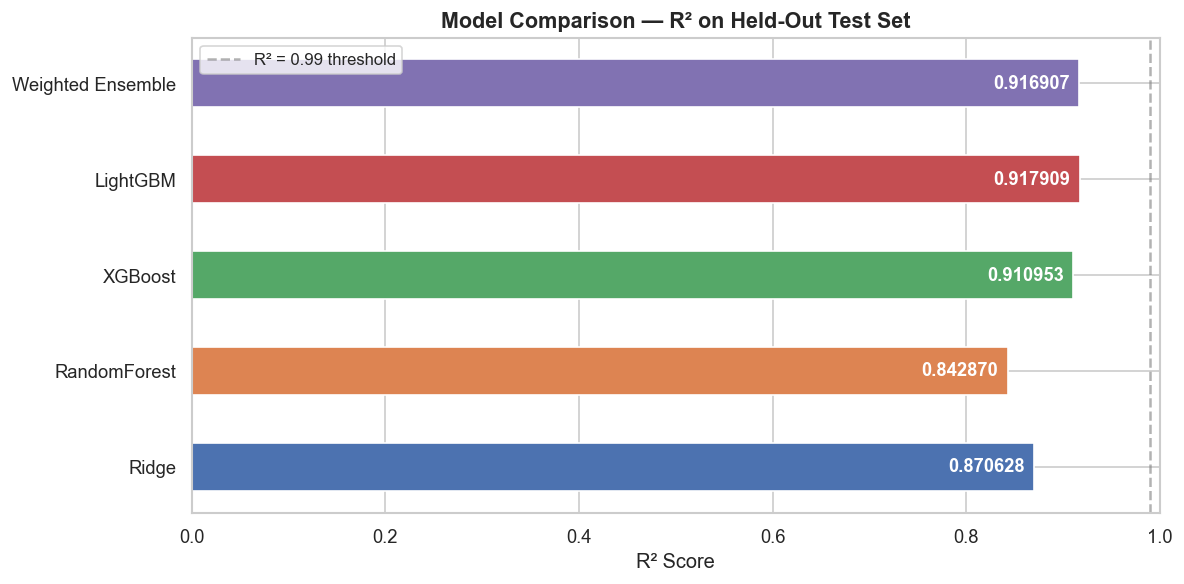

In [21]:
# ── Bar chart: R² comparison ──────────────────────────────────────────────────
r2_vals = {k: v["R²"] for k, v in results.items()}
names = list(r2_vals.keys())
scores = list(r2_vals.values())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, scores, color=colors[: len(names)], edgecolor="white", height=0.5)
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_width() - 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.6f}",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
        fontsize=11,
    )
ax.set_xlim(0, 1.0)
ax.set_xlabel("R² Score", fontsize=12)
ax.set_title(
    "Model Comparison — R² on Held-Out Test Set", fontsize=13, fontweight="bold"
)
ax.axvline(0.99, linestyle="--", color="gray", alpha=0.6, label="R² = 0.99 threshold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

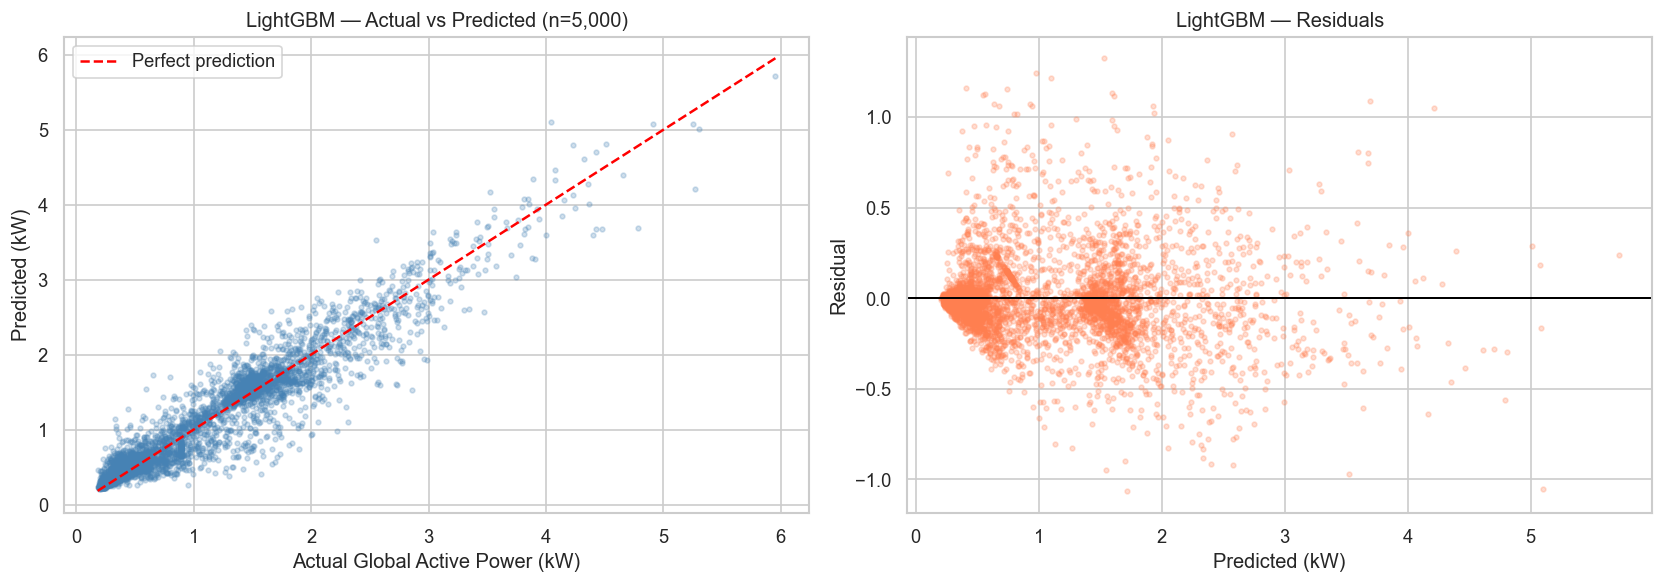

In [22]:
# ── Actual vs Predicted scatter (best model = LightGBM) ──────────────────────
sample_n = 5000
idx = np.random.choice(len(y_test), sample_n, replace=False)
y_s = np.array(y_test)[idx]
p_s = y_pred_lgb[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_s, p_s, alpha=0.25, s=8, color="steelblue")
mn, mx = y_s.min(), y_s.max()
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Global Active Power (kW)")
axes[0].set_ylabel("Predicted (kW)")
axes[0].set_title(f"LightGBM — Actual vs Predicted (n={sample_n:,})")
axes[0].legend()

# Residuals
resid = y_s - p_s
axes[1].scatter(p_s, resid, alpha=0.25, s=8, color="coral")
axes[1].axhline(0, color="black", linewidth=1.2)
axes[1].set_xlabel("Predicted (kW)")
axes[1].set_ylabel("Residual")
axes[1].set_title("LightGBM — Residuals")

plt.tight_layout()
plt.show()

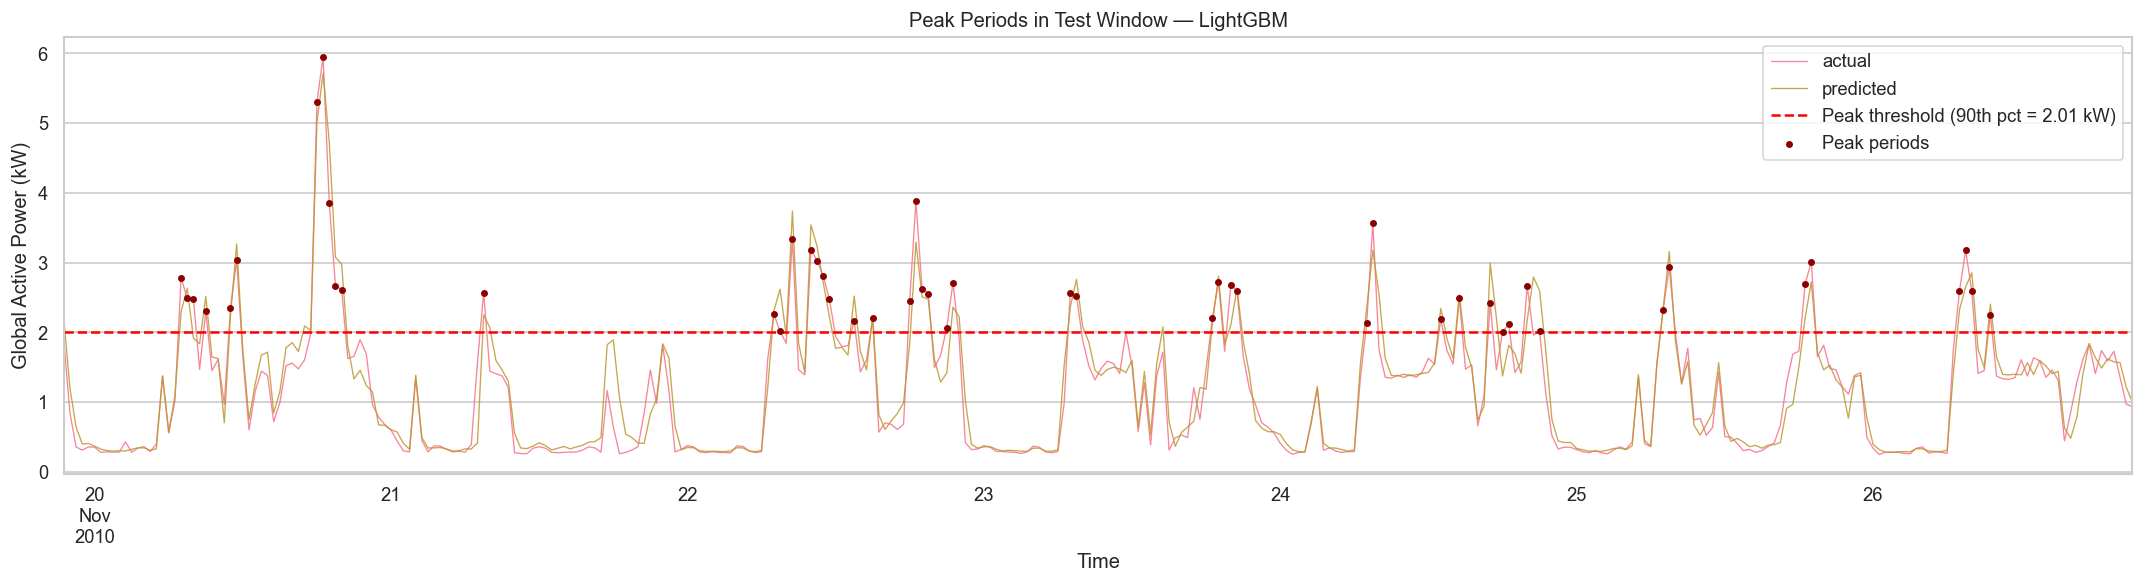

Detected peak periods: 1,384 (10.0%)
Daily time-of-day classifier accuracy: 0.986
Recommended backup window (next day): 06:00 - 11:59
Predicted time of day: Morning


In [24]:
# ── Peak-demand detection + next-day time-of-day prediction ───────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Pick the best regressor dynamically from the already-computed test results.
model_preds = {
    "Ridge": y_pred_ridge,
    "RandomForest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "WeightedEnsemble": y_pred_meta,
}
best_model_name = max(results.items(), key=lambda kv: kv[1]["R²"])[0]
best_pred = model_preds[best_model_name]

comparison_df = pd.DataFrame(
    {"actual": y_test.values, "predicted": best_pred}, index=y_test.index
)
peak_threshold = comparison_df["actual"].quantile(0.90)
comparison_df["is_peak"] = comparison_df["actual"] >= peak_threshold
peak_periods = comparison_df[comparison_df["is_peak"]].copy()

fig, ax = plt.subplots(figsize=(18, 5))
comparison_df[["actual", "predicted"]].tail(7 * 24 * 2).plot(
    ax=ax, linewidth=0.8, alpha=0.85
)
ax.axhline(
    peak_threshold,
    color="red",
    linestyle="--",
    label=f"Peak threshold (90th pct = {peak_threshold:.2f} kW)",
)
if not peak_periods.empty:
    recent_peaks = peak_periods.tail(7 * 24 * 2)
    ax.scatter(
        recent_peaks.index,
        recent_peaks["actual"],
        color="darkred",
        s=10,
        label="Peak periods",
        zorder=4,
    )
ax.set_title(f"Peak Periods in Test Window — {best_model_name}")
ax.set_ylabel("Global Active Power (kW)")
ax.set_xlabel("Time")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Detected peak periods: {len(peak_periods):,} ({len(peak_periods) / len(comparison_df) * 100:.1f}%)"
)

# Daily time-of-day prediction on hourly-resampled data (easier than 24-way peak-hour classification)
df_hourly = df.resample("1h").mean().dropna().copy()
daily_df = (
    df_hourly.assign(date=df_hourly.index.date)
    .groupby("date")
    .agg(
        day_mean=("Global_active_power", "mean"),
        day_max=("Global_active_power", "max"),
        day_std=("Global_active_power", "std"),
        peak_hour=("Global_active_power", lambda s: int(s.idxmax().hour)),
    )
)

daily_df.index = pd.to_datetime(daily_df.index)
daily_df["day_of_week"] = daily_df.index.dayofweek
daily_df["month"] = daily_df.index.month
daily_df["is_weekend"] = (daily_df["day_of_week"] >= 5).astype(int)
for c in ["day_mean", "day_max", "day_std"]:
    daily_df[f"prev_{c}"] = daily_df[c].shift(1)


# Convert to four broader and more learnable classes.
def peak_hour_to_time_of_day(hour: int) -> int:
    if hour < 6:
        return 0  # Night
    if hour < 12:
        return 1  # Morning
    if hour < 18:
        return 2  # Afternoon
    return 3  # Evening


def time_of_day_to_label(idx: int) -> str:
    return {0: "Night", 1: "Morning", 2: "Afternoon", 3: "Evening"}.get(idx, "Unknown")


def time_of_day_to_window(idx: int) -> tuple[int, int]:
    return {
        0: (0, 5),
        1: (6, 11),
        2: (12, 17),
        3: (18, 23),
    }.get(idx, (0, 23))


def time_of_day_to_representative_hour(idx: int) -> int:
    return {0: 2, 1: 9, 2: 15, 3: 21}.get(idx, 12)


daily_df["peak_time_of_day"] = daily_df["peak_hour"].apply(peak_hour_to_time_of_day)

daily_df = daily_df.dropna().copy()
peak_feature_cols = [c for c in daily_df.columns if c != "peak_time_of_day"]
split_daily = int(len(daily_df) * 0.8)
X_peak_train = daily_df.iloc[:split_daily][peak_feature_cols]
y_peak_train = daily_df.iloc[:split_daily]["peak_time_of_day"]
X_peak_test = daily_df.iloc[split_daily:][peak_feature_cols]
y_peak_test = daily_df.iloc[split_daily:]["peak_time_of_day"]

peak_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
peak_model.fit(X_peak_train, y_peak_train)
y_peak_pred = peak_model.predict(X_peak_test)
peak_hour_accuracy = accuracy_score(y_peak_test, y_peak_pred)

latest_features_daily = daily_df.iloc[-1][peak_feature_cols].to_frame().T
predicted_peak_time_of_day_next_day = int(peak_model.predict(latest_features_daily)[0])
predicted_peak_hour_next_day = time_of_day_to_representative_hour(
    predicted_peak_time_of_day_next_day
)
backup_start, backup_end = time_of_day_to_window(predicted_peak_time_of_day_next_day)

print(f"Daily time-of-day classifier accuracy: {peak_hour_accuracy:.3f}")
print(
    f"Recommended backup window (next day): {backup_start:02d}:00 - {backup_end:02d}:59"
)
print(
    f"Predicted time of day: {time_of_day_to_label(predicted_peak_time_of_day_next_day)}"
)


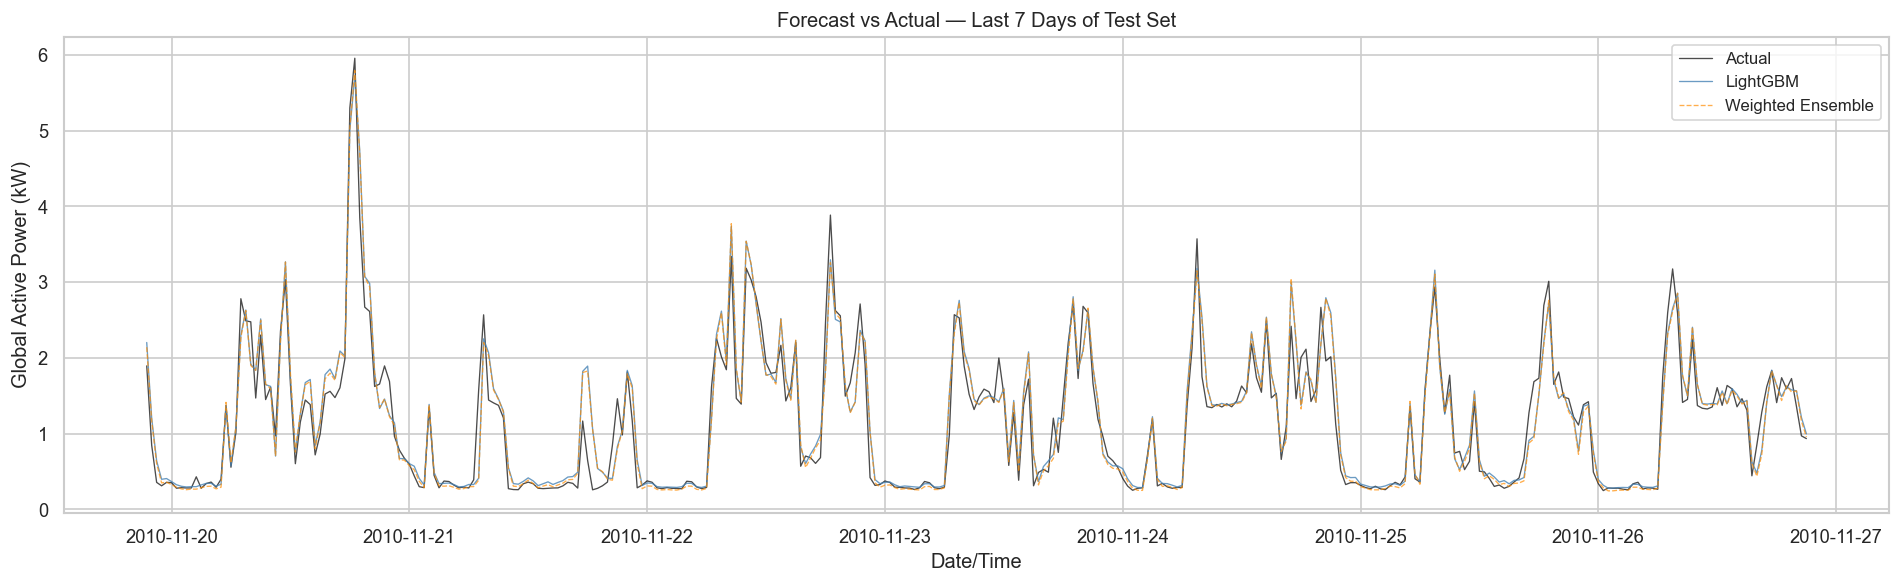

In [26]:
# ── Time-series forecast plot (last 7 days) ───────────────────────────────────
last_7d = 7 * 24 * 2  # 7 days in 30-min periods
ts_idx = df_feat.index[split_idx:][-last_7d:]
ts_y = np.array(y_test)[-last_7d:]
ts_lgb = y_pred_lgb[-last_7d:]
ts_stack = y_pred_meta[-last_7d:]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts_idx, ts_y, color="black", alpha=0.7, linewidth=0.8, label="Actual")
ax.plot(ts_idx, ts_lgb, color="steelblue", alpha=0.8, linewidth=0.8, label="LightGBM")
ax.plot(
    ts_idx,
    ts_stack,
    color="darkorange",
    alpha=0.7,
    linewidth=0.8,
    linestyle="--",
    label="Weighted Ensemble",
)
ax.set_xlabel("Date/Time")
ax.set_ylabel("Global Active Power (kW)")
ax.set_title("Forecast vs Actual — Last 7 Days of Test Set")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

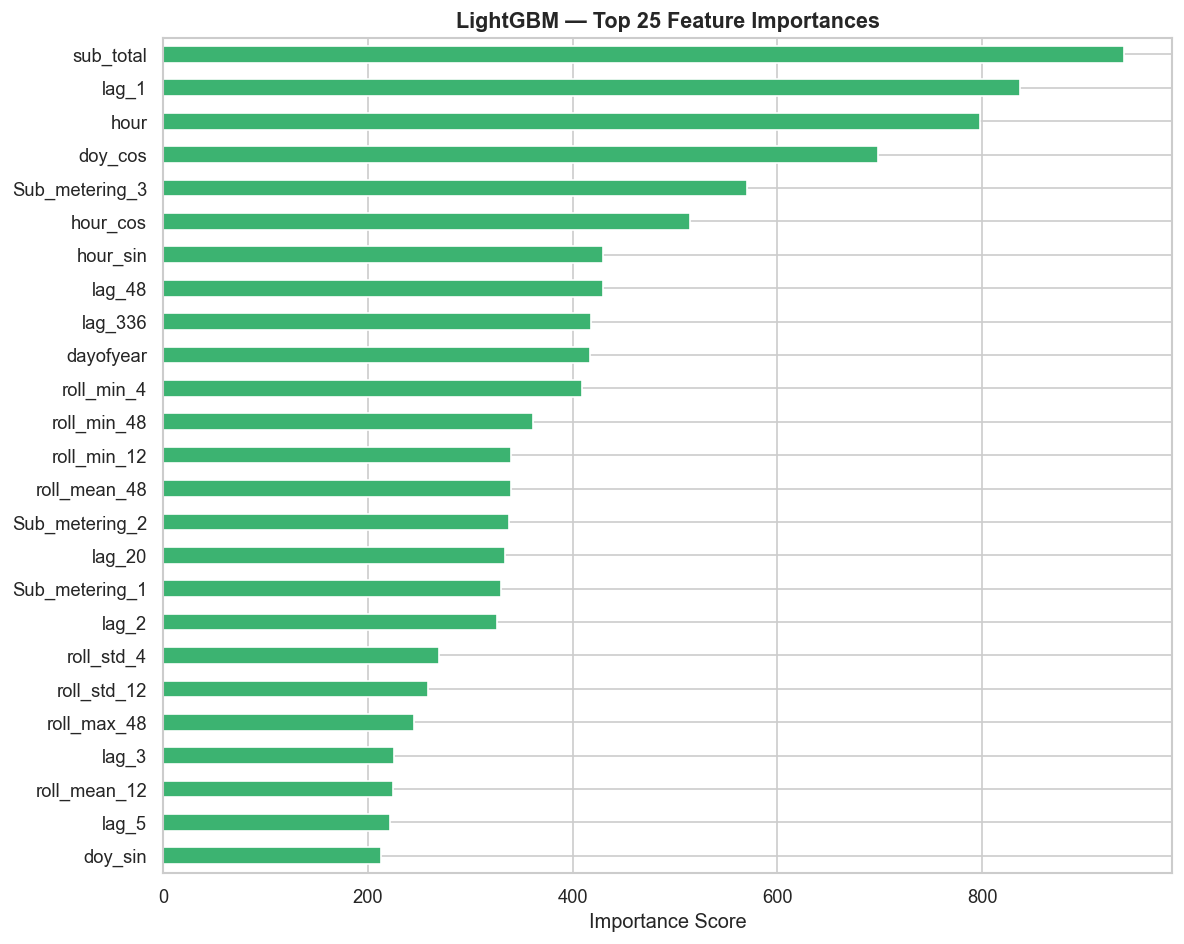

In [27]:
# ── Feature importance (LightGBM top 25) ─────────────────────────────────────
imp = pd.Series(lgb_model.feature_importances_, index=FEATURES)
top25 = imp.nlargest(25).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top25.plot.barh(ax=ax, color="mediumseagreen", edgecolor="white")
ax.set_title("LightGBM — Top 25 Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [29]:
# ── Save models, metrics, and app artifact ────────────────────────────────────
import joblib

from src.config import (
    ARTIFACT_PATH,
    COMPARISON_PATH,
    METRICS_PATH,
    PEAK_PERIODS_PATH,
    MODEL_EXPORT_DIR,
)

MODEL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

# Rebuild a save-friendly metrics table that includes the notebook's ensemble.
predictions_map = {
    "Ridge": y_pred_ridge,
    "RandomForest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "WeightedEnsemble": y_pred_meta,
}


def summarize(name, yt, yp):
    den = np.abs(yt - yt.mean()).sum()
    rae = float(np.abs(yt - yp).sum() / den) if den > 0 else 0.0
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(yt, yp)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "R2": float(r2_score(yt, yp)),
        "MAPE": float(np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-8))) * 100),
        "RAE": rae,
        "Accuracy": (1.0 - rae) * 100,
    }


results_rows = [
    summarize(name, y_test.values, pred) for name, pred in predictions_map.items()
]
results_df_save = pd.DataFrame(results_rows).sort_values("RMSE").reset_index(drop=True)
best_model_name_save = str(results_df_save.iloc[0]["Model"])
ensemble_models_save = {
    "Ridge": ridge,
    "RandomForest": rf,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
}
ensemble_weights_save = {
    "RandomForest": float(meta_lr.coef_[0]),
    "XGBoost": float(meta_lr.coef_[1]),
    "LightGBM": float(meta_lr.coef_[2]),
}

if best_model_name_save == "WeightedEnsemble":
    best_model_save = None
    best_pred_save = predictions_map[best_model_name_save]
    # Keep the app-compatible ensemble branch active.
    app_best_model_name = "WeightedEnsemble"
else:
    best_model_save = {
        "Ridge": ridge,
        "RandomForest": rf,
        "XGBoost": xgb_model,
        "LightGBM": lgb_model,
        "WeightedEnsemble": None,
    }[best_model_name_save]
    best_pred_save = predictions_map[best_model_name_save]
    app_best_model_name = best_model_name_save

comparison_df_save = pd.DataFrame(
    {"datetime": y_test.index, "actual": y_test.values, "predicted": best_pred_save}
).set_index("datetime")
peak_threshold_save = comparison_df_save["actual"].quantile(0.90)
peak_periods_save = comparison_df_save[
    comparison_df_save["actual"] >= peak_threshold_save
].copy()

# Daily peak-period artifact for backup scheduling.
daily_peak_comparison_df_save = pd.DataFrame(
    {
        "date": daily_df.index[split_daily:],
        "actual_peak_time_of_day": y_peak_test.values,
        "predicted_peak_time_of_day": y_peak_pred,
    }
).set_index("date")

time_of_day_labels = {0: "Night", 1: "Morning", 2: "Afternoon", 3: "Evening"}


def time_of_day_to_window(idx: int) -> tuple[int, int]:
    return {
        0: (0, 5),
        1: (6, 11),
        2: (12, 17),
        3: (18, 23),
    }.get(idx, (0, 23))


def time_of_day_to_representative_hour(idx: int) -> int:
    return {0: 2, 1: 9, 2: 15, 3: 21}.get(idx, 12)


# Export individual model files and an app-compatible bundle.
model_paths = {}
for name, model in ensemble_models_save.items():
    model_path = MODEL_EXPORT_DIR / f"{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, model_path)
    model_paths[name] = str(model_path)

best_model_path = (
    MODEL_EXPORT_DIR / f"best_{app_best_model_name.lower().replace(' ', '_')}.joblib"
)
if best_model_save is not None:
    joblib.dump(best_model_save, best_model_path)
else:
    joblib.dump(
        {
            "best_model_name": app_best_model_name,
            "models": ensemble_models_save,
            "weights": ensemble_weights_save,
            "meta_learner": meta_lr,
        },
        best_model_path,
    )
model_paths["best_model"] = str(best_model_path)

# ensure backup_power_time_window is defined (don't overwrite if already set)
if "backup_power_time_window" not in globals():
    # fallback to backup_start/backup_end if available
    try:
        backup_power_time_window = (int(backup_start), int(backup_end))
    except Exception:
        # final fallback: full-day window
        backup_power_time_window = (0, 23)

artifact_payload = {
    "results_df": results_df_save,
    "comparison_df": comparison_df_save,
    "peak_periods": peak_periods_save,
    "peak_threshold": float(peak_threshold_save),
    "best_model_name": app_best_model_name,
    "best_model": best_model_save,
    "ensemble_models": ensemble_models_save,
    "ensemble_weights": ensemble_weights_save,
    "feature_cols": list(X_train.columns),
    "latest_features": X_test.iloc[-1],
    "latest_timestamp": str(df_feat.index[-1]),
    "target_col": TARGET,
    "daily_peak_model": {"RandomForest": peak_model},
    "daily_peak_ensemble_weights": {"RandomForest": 1.0},
    "daily_peak_feature_cols": peak_feature_cols,
    "latest_daily_features": latest_features_daily,
    "daily_peak_accuracy": float(peak_hour_accuracy),
    "daily_peak_comparison_df": daily_peak_comparison_df_save,
    "predicted_peak_time_of_day_next_day": int(predicted_peak_time_of_day_next_day),
    "predicted_peak_time_of_day_label": time_of_day_labels[
        int(predicted_peak_time_of_day_next_day)
    ],
    "predicted_peak_hour_next_day": int(predicted_peak_hour_next_day),
    "backup_power_time_window": backup_power_time_window,
    "model_paths": model_paths,
    "best_metrics": results_df_save.iloc[0].to_dict(),
}

joblib.dump(artifact_payload, ARTIFACT_PATH)
results_df_save.to_csv(METRICS_PATH, index=False)
comparison_df_save.to_csv(COMPARISON_PATH)
peak_periods_save.to_csv(PEAK_PERIODS_PATH)

print("✅ Saved new model artifact and reports")
print(f"Artifact : {ARTIFACT_PATH}")
print(f"Metrics  : {METRICS_PATH}")
print(f"Compare  : {COMPARISON_PATH}")
print(f"Peaks    : {PEAK_PERIODS_PATH}")
print("Top metrics:")
print(results_df_save.head(5).to_string(index=False))


✅ Saved new model artifact and reports
Artifact : /home/temi/Documents/clones/End-to-End-Smart-Power/models/power_forecast.joblib
Metrics  : /home/temi/Documents/clones/End-to-End-Smart-Power/reports/model_metrics.csv
Compare  : /home/temi/Documents/clones/End-to-End-Smart-Power/reports/test_comparison.csv
Peaks    : /home/temi/Documents/clones/End-to-End-Smart-Power/reports/peak_periods.csv
Top metrics:
           Model      MAE     RMSE       R2      MAPE      RAE  Accuracy
        LightGBM 0.143630 0.223610 0.917909 17.176376 0.224801 77.519897
WeightedEnsemble 0.142813 0.224970 0.916907 16.415271 0.223522 77.647809
         XGBoost 0.153233 0.232891 0.910953 18.933538 0.239830 76.016982
           Ridge 0.201414 0.280713 0.870628 26.790276 0.315240 68.476000
    RandomForest 0.210882 0.309366 0.842870 26.808343 0.330059 66.994091


---
### Notes
- The daily peak model now predicts a broader time-of-day bucket instead of a 24-class peak hour, which is usually much easier to learn and more stable.
- The notebook overwrites `models/power_forecast.joblib` and the CSV reports in `reports/` whenever the save cell is run.
- Re-run the notebook after changing features or models so Streamlit picks up the refreshed artifact.

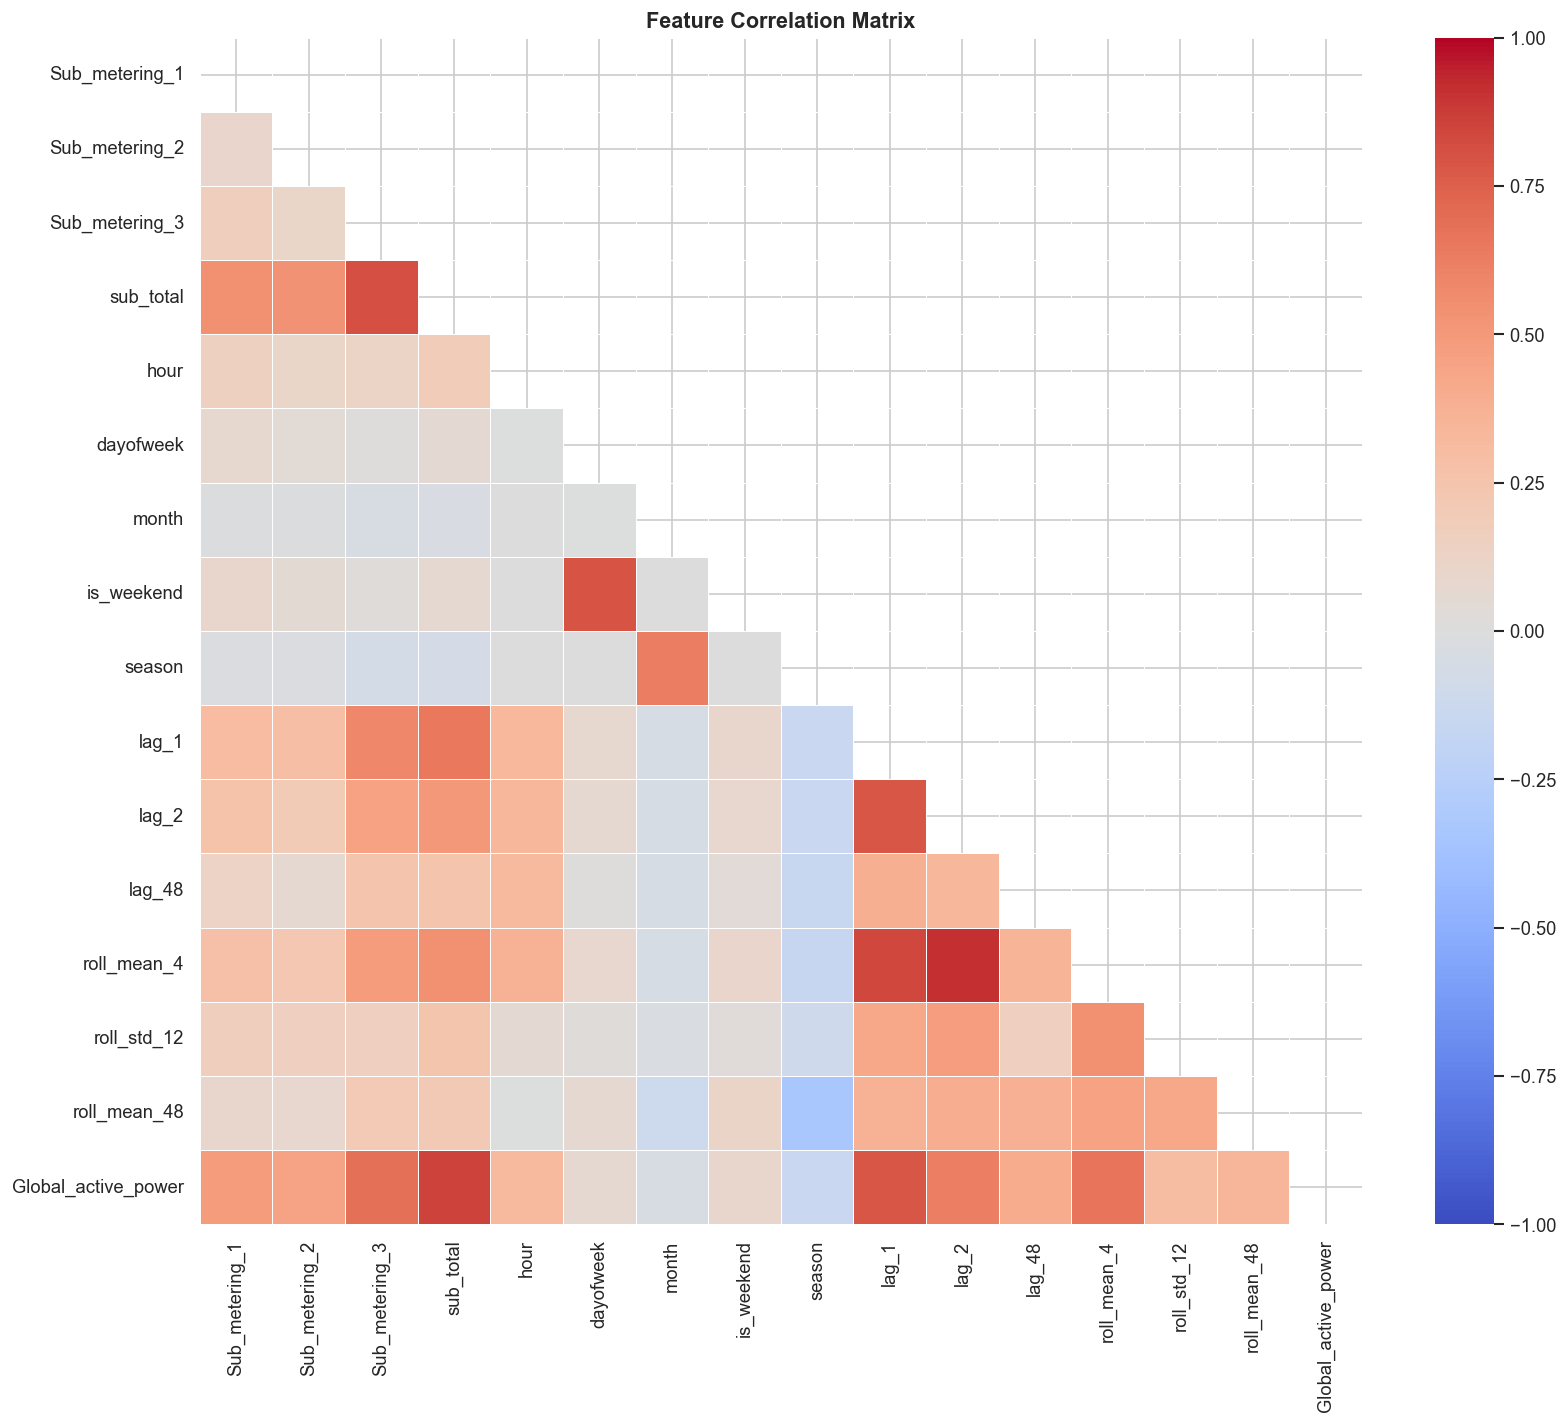

In [30]:
# ── Correlation heat-map of engineered features ───────────────────────────────
core_feats = [
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "sub_total",
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "season",
    "lag_1",
    "lag_2",
    "lag_48",
    "roll_mean_4",
    "roll_std_12",
    "roll_mean_48",
    TARGET,
]

corr = df_feat[core_feats].sample(50_000, random_state=SEED).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3,
    ax=ax,
    vmin=-1,
    vmax=1,
)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()